# Reflective surface testing

This notebook tests the backend setup for a diffuse surface without an
atmosphere.

In [1]:
import eradiate
import matplotlib.pyplot as plt
import seaborn as sns

import eradiate_disort as ed
from eradiate_disort.testing import TestMode, cases
from eradiate_disort.testing.util import Result, disort_reshape_pplane

sns.set_theme(style="ticks")

eradiate.set_mode("ckd")

_base_spp = TestMode.spp(tutorial=1_000, test=10_000)
SPP = _base_spp // 16 if eradiate.get_mode().is_ckd else _base_spp

In [2]:
result = Result()

exp = cases.no_atmo(30.0, backend="mitsuba")
result.mitsuba = eradiate.run(exp, spp=SPP)["radiance"].squeeze()

exp = cases.no_atmo(30.0, backend="disort")
backend = ed.EradiateDisortBackend()
result.disort = disort_reshape_pplane(backend.run(exp).sel(z=1.0))

0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

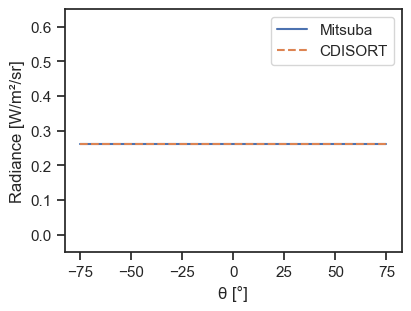

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3), layout="constrained")

ax.plot(result.mitsuba["vza"], result.mitsuba, label="Mitsuba")
ax.plot(result.disort["vza"], result.disort, label="CDISORT", ls="--")
ax.set_xlabel("θ [°]")
ax.set_ylabel("Radiance [W/m²/sr]")
ax.set_ylim([-0.05, 0.65])
ax.legend()

plt.show()